In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df_fe = pd.read_csv("../data/processed/final_dataset.csv")

In [3]:
#Separate features and target
X = df_fe.drop("Credit_Score", axis=1)
y = df_fe["Credit_Score"]

In [4]:
#check shapes
print(X.shape)
print(y.shape)

(100000, 50)
(100000,)


In [5]:
#Train-test split: Use an 80:20 split.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Why stratify=y?

It ensures the proportions of Good, Standard, and Poor credit scores remain similar in both training and testing datasets.

LOGISTIC REGRESSION

In [6]:
#Create model
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [7]:
#Train model
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [8]:
#Predict
y_pred = lr.predict(X_test)

MODEL EVALUATION

In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.62465


This is a reasonable baseline model for a multiclass credit score classification problem. Logistic Regression assumes linear relationships, whereas credit risk data is often non-linear. So it's expected that tree-based models will perform better.                   
The class distribution is imbalanced:
Class 0: 3,566
Class 1: 5,799
Class 2: 10,635

The model naturally leans toward predicting the largest class.

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.54      0.47      0.50      3566
           1       0.65      0.45      0.53      5799
           2       0.64      0.77      0.70     10635

    accuracy                           0.62     20000
   macro avg       0.61      0.56      0.58     20000
weighted avg       0.62      0.62      0.61     20000



Macro F1-score: 0.58  Average performance across all classes.

Weighted F1-score: 0.61  Reflects class frequencies and is close to the overall accuracy.

In [11]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1666   55 1845]
 [ 340 2617 2842]
 [1079 1346 8210]]


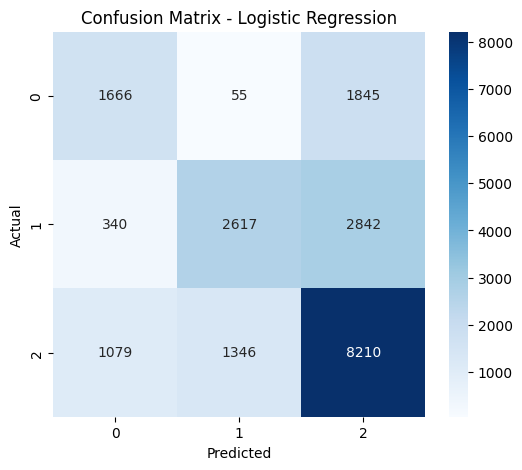

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

Class 2 has the highest number of correct predictions (8210), showing the model performs best for this class.                                     
Class 0 is frequently misclassified as Class 2 (1845 cases), indicating difficulty distinguishing these two classes.                                
Class 1 is also often predicted as Class 2 (2842 cases), suggesting the model has a bias toward predicting the majority class.

In [13]:
#Store the results in a dictionary for later comparison with other models
results = {}

results["Logistic Regression"] = accuracy

DECISION TREE

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
#create model
dt = DecisionTreeClassifier(
    random_state=42
)

In [16]:
#Train model
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [17]:
#Predict
y_pred_dt = dt.predict(X_test)

MODEL EVALUATION

In [18]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", round(dt_accuracy*100,2), "%")

Decision Tree Accuracy: 69.12 %


In [19]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.60      0.60      0.60      3566
           1       0.68      0.68      0.68      5799
           2       0.73      0.73      0.73     10635

    accuracy                           0.69     20000
   macro avg       0.67      0.67      0.67     20000
weighted avg       0.69      0.69      0.69     20000



The model predicts Class 2 (likely the majority class) most accurately.                      
Performance for Class 1 has improved compared to Logistic Regression.                       
Class 0 remains the most challenging class, though it also shows improvement.

In [20]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[2142  209 1215]
 [ 216 3923 1660]
 [1222 1653 7760]]


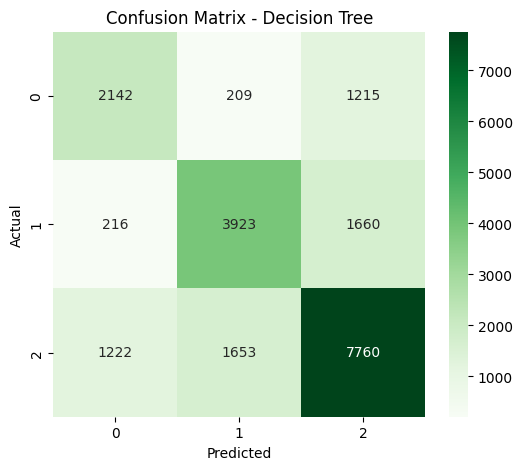

In [21]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

Class 0:
2,142 samples were correctly classified.
1,215 samples were incorrectly predicted as Class 2.
Only 209 were confused with Class 1.

Class 1:
3,923 correctly classified.
Most errors were predictions as Class 2 (1,660).

Class 2:
7,760 correctly classified.
Some were confused with Classes 0 and 1, but the majority were correctly identified.

The confusion matrix indicates that most prediction errors occur between neighboring credit score classes rather than being completely incorrect, suggesting the model captures the overall creditworthiness patterns reasonably well.

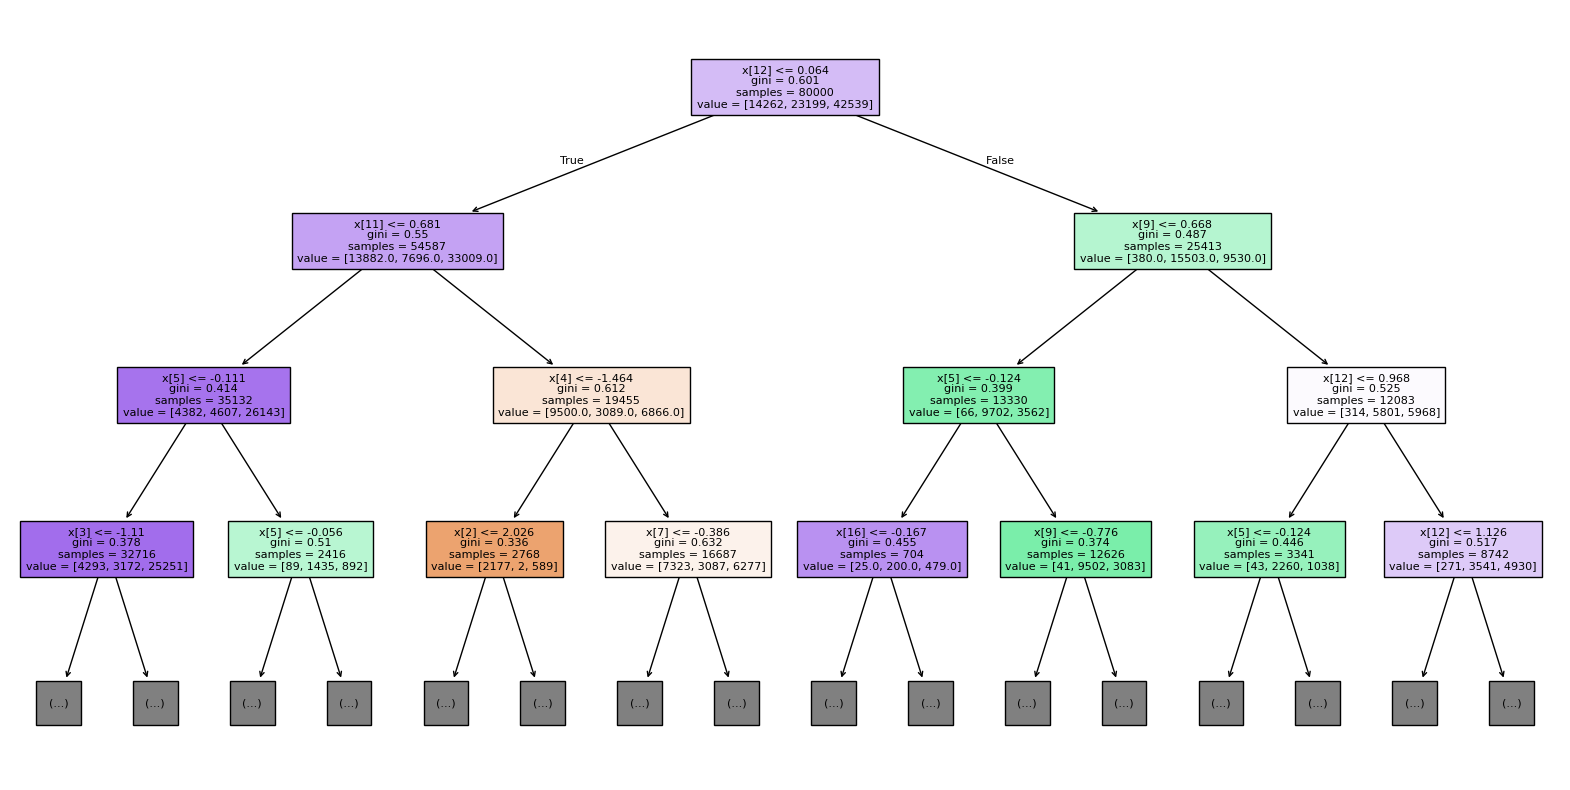

In [22]:
#Visualize decision tree (upto 3 levels only)
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    max_depth=3,
    filled=True,
    fontsize=8
)

plt.show()

The Decision Tree identified Outstanding_Debt as the most influential feature, followed by Credit_Mix, Interest_Rate, Changed_Credit_Limit, and Credit_History_Age. These variables form the primary decision rules used to classify customer credit scores. The inclusion of engineered features such as Debt_to_Income, Investment_Ratio, and EMI_Ratio also contributed to the model, indicating that they captured additional financial patterns beyond the original dataset. The hierarchical structure of the tree demonstrates that the model first evaluates debt-related characteristics before considering repayment behavior and credit history, which aligns well with established credit risk assessment practices.

In [23]:
#Feature Importance
importance_dt = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

importance_dt = importance_dt.sort_values(
    by="Importance",
    ascending=False
)

print(importance_dt.head(20))

                     Feature  Importance
12          Outstanding_Debt    0.164308
11                Credit_Mix    0.082986
5              Interest_Rate    0.067208
9       Changed_Credit_Limit    0.054674
14        Credit_History_Age    0.050648
7        Delay_from_due_date    0.045139
13  Credit_Utilization_Ratio    0.040335
17   Amount_invested_monthly    0.033976
21          Investment_Ratio    0.033042
0                        Age    0.032869
20                 EMI_Ratio    0.032608
19            Debt_to_Income    0.032587
8     Num_of_Delayed_Payment    0.031569
3          Num_Bank_Accounts    0.030958
4            Num_Credit_Card    0.030785
16       Total_EMI_per_month    0.030306
2      Monthly_Inhand_Salary    0.030037
1              Annual_Income    0.028179
10      Num_Credit_Inquiries    0.023716
23          Loan_per_Account    0.019077


Hence, feature engineering improved the dataset.

In [24]:
#Store results
results["Decision Tree"] = dt_accuracy

1. Learn non-linear decision boundaries.
2. Handle interactions between features without manual feature engineering.
3. Work well with mixed numerical and categorical features after preprocessing.

In [25]:
#Compare with Logistic Regression
comparison = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
})

comparison

,Model,Accuracy
0,Logistic Regression,0.62465
1,Decision Tree,0.69125


The Decision Tree outperformed the Logistic Regression model by capturing non-linear relationships in the credit scoring data.

RANDOM FOREST

In [26]:
#Import libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [27]:
#Create model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

n_estimators=200 → Builds 200 decision trees.                                         
random_state=42 → Ensures reproducible results.                  
n_jobs=-1 → Uses all CPU cores for faster training.

In [28]:
#Train model
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
#Predict
y_pred_rf = rf.predict(X_test)

MODEL EVALUATION

In [30]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy*100,2), "%")

Random Forest Accuracy: 78.89 %


This clearly shows that the ensemble approach of Random Forest captures the complex relationships in the data much better.

In [31]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.73      0.73      0.73      3566
           1       0.79      0.79      0.79      5799
           2       0.81      0.81      0.81     10635

    accuracy                           0.79     20000
   macro avg       0.78      0.78      0.78     20000
weighted avg       0.79      0.79      0.79     20000



The model performs consistently across all classes, indicating a well-balanced classifier.

In [32]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[2586    9  971]
 [ 140 4606 1053]
 [ 802 1248 8585]]


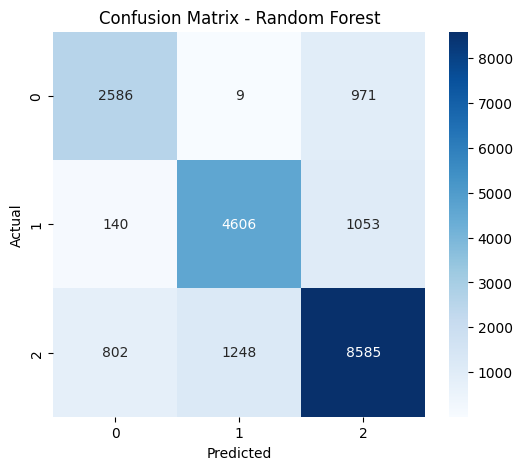

In [33]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Class 0
Correct predictions: 2586
Very few misclassified as Class 1 (9).
Most errors are confusion with Class 2.

Class 1
Correct predictions: 4606
The majority of errors are predictions as Class 2.

Class 2
Correct predictions: 8585
This class has the highest number of correct predictions.

Overall, the confusion matrix has a much stronger diagonal than the previous models, which indicates improved classification performance.

In [34]:
#Feature Importance
importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by="Importance",
    ascending=False
)

importance_rf.head(20)

,Feature,Importance
12,Outstanding_Debt,0.094986
5,Interest_Rate,0.069072
7,Delay_from_due_date,0.055253
9,Changed_Credit_Limit,0.050835
11,Credit_Mix,0.049824
19,Debt_to_Income,0.048934
14,Credit_History_Age,0.048810
4,Num_Credit_Card,0.039678
10,Num_Credit_Inquiries,0.038384
13,Credit_Utilization_Ratio,0.036678


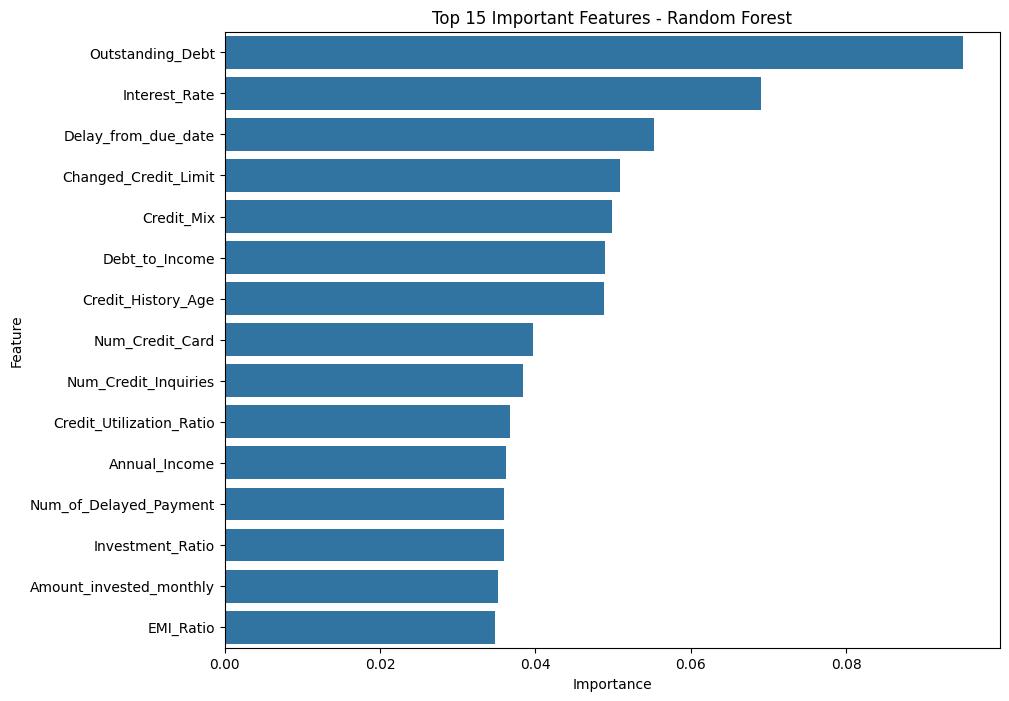

In [35]:
#Plot Feature Importance
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance_rf.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features - Random Forest")

plt.show()

In [36]:
#Store results
results["Random Forest"] = rf_accuracy

Random Forest combines the predictions of many decision trees, which Reduces overfitting compared to a single Decision Tree, Captures complex, non-linear relationships in financial data, Is more robust to noisy data and outliers and Produces more stable and accurate predictions.

In [37]:
#Compare all models
comparison = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
})

comparison

,Model,Accuracy
0,Logistic Regression,0.62465
1,Decision Tree,0.69125
2,Random Forest,0.78885


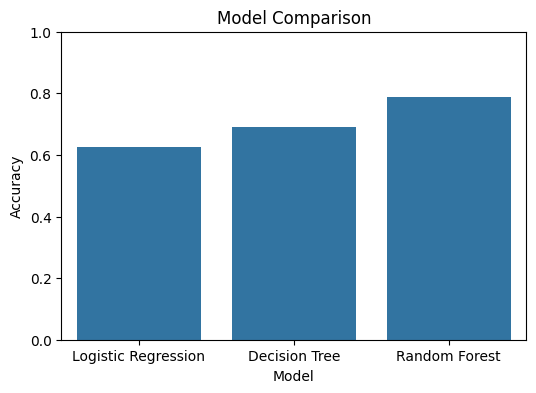

In [38]:
#Plot model comparison
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Comparison")
plt.ylim(0,1)

plt.show()

The Random Forest classifier achieved the best performance among all evaluated models, with an accuracy of 79% and a weighted F1-score of 0.79. It consistently outperformed Logistic Regression and Decision Tree across all evaluation metrics. The confusion matrix shows a high number of correct classifications for each credit score class, demonstrating the model's ability to distinguish customers with different credit risk levels. Due to its higher predictive performance and balanced results, Random Forest is selected as the final model for the credit score prediction system.

HYPERPARAMETER TUNING

In [39]:
#Import libraries
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

I recommend RandomizedSearchCV because it's much faster than GridSearchCV while still finding good parameters.We can explore a broad parameter space with much less computation.

In [40]:
#Create base model
rf = RandomForestClassifier(random_state=42)

In [41]:
#Define hyperparameter search space
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

Parameter	           Purpose                               
n_estimators    :  	Number of trees                           
max_depth	     :   Maximum depth of each tree                               
min_samples_split:	Minimum samples required to split a node                         
min_samples_leaf:	Minimum samples in each leaf                                       
max_features	 :   Number of features considered at each split                        
bootstrap	      :  Whether to sample with replacement                                               

In [42]:
#Create RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring="accuracy"
)

n_iter=20 → Tests 20 random parameter combinations.                         
cv=5 → 5-fold cross-validation.                                 
n_jobs=-1 → Uses all CPU cores.                                     
scoring='accuracy' → Optimizes for accuracy.                       

In [43]:
#Train the Search
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here...

In [44]:
#View best parameters
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}


In [45]:
#View best cross-validation score
print("Best CV Accuracy:")
print(random_search.best_score_)

Best CV Accuracy:
0.7866375


In [46]:
#Get best model
best_rf = random_search.best_estimator_

In [47]:
#Predict on test data
y_pred_best = best_rf.predict(X_test)

MODEL EVALUATION

In [48]:
best_accuracy = accuracy_score(y_test, y_pred_best)

print("Tuned Random Forest Accuracy:",
      round(best_accuracy*100,2), "%")

Tuned Random Forest Accuracy: 79.47 %


In [49]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.75      0.73      0.74      3566
           1       0.79      0.80      0.80      5799
           2       0.81      0.81      0.81     10635

    accuracy                           0.79     20000
   macro avg       0.78      0.78      0.78     20000
weighted avg       0.79      0.79      0.79     20000



The tuned model maintained balanced performance across all three credit score classes while achieving the highest overall accuracy among all evaluated models.

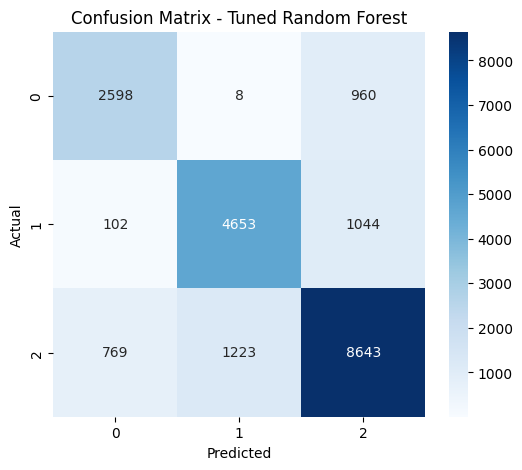

In [50]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Class 2 remains the best-predicted class.                                      
Class 1 is classified very effectively with balanced precision and recall.                      
Class 0 continues to be the most challenging class but still achieves a respectable F1-score of 0.74.

In [51]:
#Comparison
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        0.62,
        0.69,
        0.79,
        best_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.6200
1,Decision Tree,0.6900
2,Random Forest,0.7900
3,Tuned Random Forest,0.7947


The improvement from tuning is 0.47%, which is perfectly normal. Hyperparameter tuning often yields incremental gains once a strong model is already in place. Based on these results, the Tuned Random Forest was selected as the final model for the credit score prediction system.

In [52]:
#Save best model
import joblib

joblib.dump(best_rf, "best_forest_credit_score.pkl")

['best_forest_credit_score.pkl']

In [53]:
#Save feature names: ensure future prediction data uses the same feature order
joblib.dump(list(X.columns), "feature_names.pkl")

['feature_names.pkl']

In [54]:
#Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
12,Outstanding_Debt,0.109870
5,Interest_Rate,0.081053
11,Credit_Mix,0.059498
7,Delay_from_due_date,0.056469
19,Debt_to_Income,0.051543
9,Changed_Credit_Limit,0.050860
14,Credit_History_Age,0.047905
4,Num_Credit_Card,0.044903
10,Num_Credit_Inquiries,0.040425
1,Annual_Income,0.036331


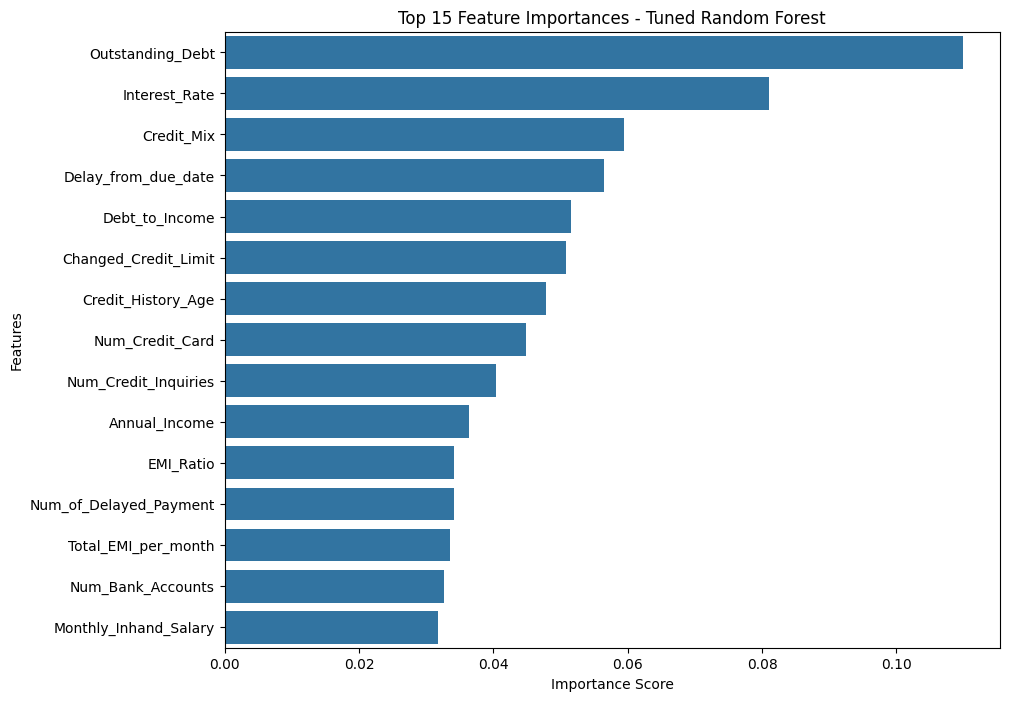

In [55]:
#Plot Feature Importance
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - Tuned Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

The feature importance analysis of the tuned Random Forest model indicates that Outstanding_Debt is the most influential predictor of credit score, followed by Interest_Rate, Credit_Mix, Delay_from_due_date, and Debt_to_Income. These results suggest that debt burden, repayment behavior, and credit management practices have the greatest impact on an individual's creditworthiness. Furthermore, engineered features such as Debt_to_Income, EMI_Ratio, and Investment_Ratio contributed significantly to the model, demonstrating that feature engineering enhanced predictive performance. Overall, the analysis aligns with real-world credit risk assessment, where repayment history and debt management are considered more important than income or demographic characteristics alone.